# Sunlight, buildings and a 3D shadow map

Inspired by day-to-night city exploration in **Hangzhou in Three.js**, SuSu_酥酥👅:
[catalog](https://github.com/magiccreator-ai/awesome-gpt-6-astra#hangzhou-in-threejs) ·
[creator post](https://x.com/NFT_Chen/status/2096143589151756638).
[Our city lighting lab](https://jltobias.github.io/JupyterLite-Astra-demos/demos/?scene=city)

**Learn:** turn a light direction and building height into a ground-plane shadow.
**Predict:** does doubling height double shadow length? What happens when the sun is near the horizon?
Synthetic geometry; azimuth is clockwise from north, elevation is above the horizon. We choose
sun angles directly rather than calculating them from a date and geographic location.


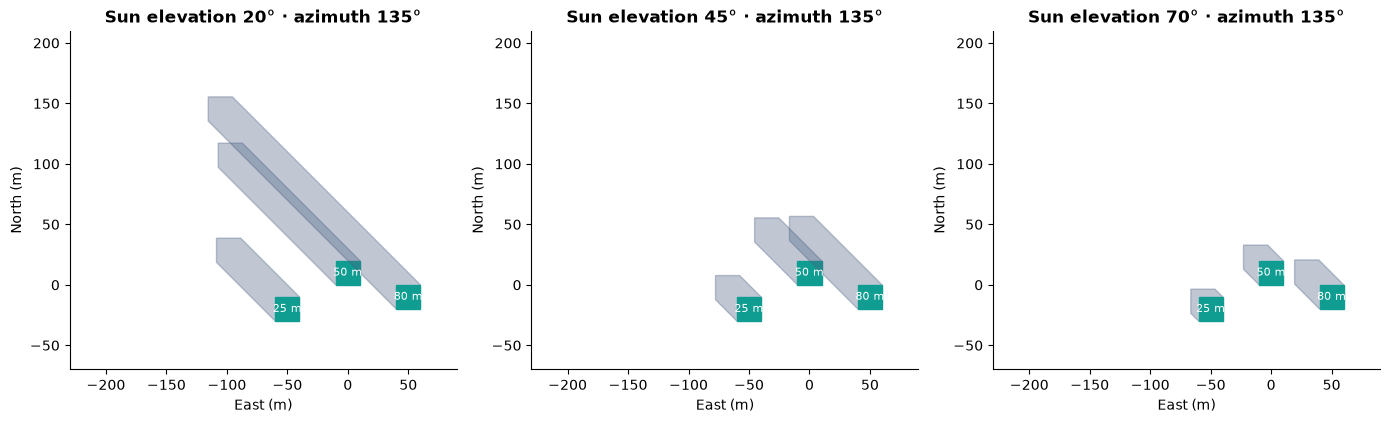

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon,Rectangle
from astra_utils import style
style()
def shadow_offset(height,elevation_deg,azimuth_deg):
    if not 0 < elevation_deg <= 90:
        raise ValueError('Sun elevation must be in (0, 90] degrees')
    length = height/np.tan(np.deg2rad(elevation_deg))
    az = np.deg2rad(azimuth_deg)
    return -length*np.array([np.sin(az),np.cos(az)])
def convex_hull(points):
    pts = sorted(set(map(tuple,points)))
    def cross(o,a,b):
        return (a[0]-o[0])*(b[1]-o[1])-(a[1]-o[1])*(b[0]-o[0])
    lower=[]
    for p in pts:
        while len(lower)>=2 and cross(lower[-2],lower[-1],p)<=0: lower.pop()
        lower.append(p)
    upper=[]
    for p in reversed(pts):
        while len(upper)>=2 and cross(upper[-2],upper[-1],p)<=0: upper.pop()
        upper.append(p)
    return np.array(lower[:-1]+upper[:-1])

buildings = [(-50,-20,25),(0,10,50),(50,-10,80)]
fig,axes = plt.subplots(1,3,figsize=(14,4.5))
for ax,elevation in zip(axes,[20,45,70]):
    for x,y,h in buildings:
        footprint=np.array([[x-10,y-10],[x+10,y-10],[x+10,y+10],[x-10,y+10]])
        offset=shadow_offset(h,elevation,135)
        hull=convex_hull(np.vstack([footprint,footprint+offset]))
        ax.add_patch(Polygon(hull,color='#4d6083',alpha=.35))
        ax.add_patch(Rectangle((x-10,y-10),20,20,color='#0f9d92'))
        ax.text(x,y,f'{h} m',ha='center',va='center',color='white',fontsize=8)
    ax.set(xlim=(-230,90),ylim=(-70,210),aspect='equal',xlabel='East (m)',ylabel='North (m)',title=f'Sun elevation {elevation}° · azimuth 135°')
fig.tight_layout()
plt.show()


The ground shadow is the convex hull of the footprint and the projected roof. Since sunlight
arrives from the southeast, shadows point northwest. The formula `length = height / tan(elevation)`
explains the dramatic change at low angles. We omit terrain slope and shadow overlap with other roofs.


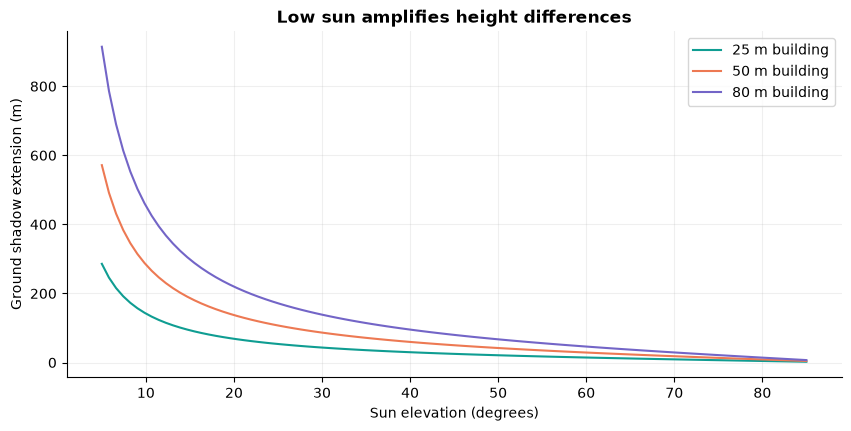

In [2]:
angles=np.linspace(5,85,100)
for h in [25,50,80]:
    plt.plot(angles,h/np.tan(np.deg2rad(angles)),label=f'{h} m building')
plt.xlabel('Sun elevation (degrees)')
plt.ylabel('Ground shadow extension (m)')
plt.title('Low sun amplifies height differences')
plt.legend()
plt.grid(alpha=.2)
plt.show()
assert np.isclose(np.linalg.norm(shadow_offset(50,45,135)),50)
assert np.allclose(shadow_offset(100,45,135),2*shadow_offset(50,45,135))


**Experiment:** change azimuth to 90° (east). Predict the shadow direction before running.
Add a tall building south of a short one and discuss why ground-plane polygons alone cannot
determine facade sunlight. Accurate planning needs surveyed geometry, terrain, solar position,
timestamps and an occlusion model. Use the World Lab to orbit a scene with actual rendered occlusion.
